# Uyghur ASR — w2v-BERT 2.0 + character CTC (Kaggle runtime)

Fine-tunes **`facebook/w2v-bert-2.0`** with a character-level CTC head and writes
`/kaggle/working/submission.csv`.

**Why a character CTC head.** The targets are a romanized Uyghur orthography: ~35 symbols,
case-significant, and the metric is CER. A CTC head over characters optimises that metric
directly — no subword mismatch, no hallucinated continuations, no autoregressive drift.
`w2v-bert-2.0` is a 580 M-parameter Conformer encoder pre-trained on 4.5 M hours of unlabeled
multilingual speech; 18 h of labels is plenty to adapt it.

**Tuned for this runtime**
* Config auto-scales to the GPU it finds (T4 ×2, P100, or anything larger).
* Memory-efficient optimiser (8-bit AdamW, else Adafactor) so 580 M params fit a 16 GB T4.
* CER/WER implemented inline — no `jiwer`, so the notebook runs with **internet off**.
* A placeholder `submission.csv` is written early and overwritten at the end, so the run
  always leaves a valid submission behind even if the session is cut short.
* Checkpoints land in `/kaggle/working`; re-running resumes instead of restarting.

### Before you run
1. **Settings → Accelerator → GPU T4 ×2** (or P100).
2. **Settings → Internet → On** so the pretrained weights can download. If the competition
   forbids internet, add `facebook/w2v-bert-2.0` as a Kaggle Model input — cell 6 finds it
   automatically anywhere under `/kaggle/input`.
3. Run all. On T4 ×2 expect ~25–35 min/epoch; the defaults are sized to finish inside the
   session with room for inference.

## 0. Runtime setup — run this cell first, before anything imports torch

In [9]:
import os

# Both T4s are used by default (transformers Trainer falls back to DataParallel, ~1.5x).
# Set to True if you hit a multi-GPU issue and want a clean single-device run.
SINGLE_GPU = False
if SINGLE_GPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Keep the 2.3 GB model download out of /kaggle/working, which has a 20 GB output quota.
os.environ["HF_HOME"] = "/kaggle/temp/hf"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.makedirs("/kaggle/temp/hf", exist_ok=True)

!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


In [10]:
import gc, glob, json, math, random, re, time, unicodedata, warnings
from dataclasses import dataclass
from fractions import Fraction
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset as TorchDataset

warnings.filterwarnings("ignore")

import transformers
print("transformers", transformers.__version__, "| torch", torch.__version__)

N_GPU = torch.cuda.device_count()
DEVICE = "cuda" if N_GPU else "cpu"
GPU_MEM = torch.cuda.get_device_properties(0).total_memory / 1e9 if N_GPU else 0.0
GPU_NAME = torch.cuda.get_device_name(0) if N_GPU else "cpu"
print(f"{N_GPU} x {GPU_NAME} | {GPU_MEM:.1f} GB each")
assert N_GPU > 0, "Turn on the GPU accelerator: Settings -> Accelerator -> GPU T4 x2"

transformers 5.0.0 | torch 2.10.0+cu128
2 x Tesla T4 | 15.6 GB each


## 1. Configuration (auto-scaled to the GPU)

In [44]:
class CFG:
    # ---- data -------------------------------------------------------------
    comp_dir       = "/kaggle/input/competitions/dlp-26-t-2-nppe-2"
    sampling_rate  = 16_000
    max_duration   = 20.0
    min_duration   = 0.4
    valid_frac     = 0.03
    seed           = 42

    # ---- model ------------------------------------------------------------
    model_id       = "facebook/w2v-bert-2.0"
    add_adapter    = False        # False -> 50 Hz CTC frames (safe for dense character text)
    ctc_zero_infinity = True
    mask_time_prob    = 0.05
    mask_time_length  = 10
    mask_feature_prob = 0.05
    mask_feature_length = 16
    layerdrop      = 0.0
    hidden_dropout = 0.0
    attention_dropout = 0.0
    activation_dropout = 0.05
    feat_proj_dropout = 0.0
    final_dropout  = 0.1

    # ---- training ---------------------------------------------------------
    output_dir     = "/kaggle/working/w2vbert-uyghur"
    epochs         = 2
           # per GPU; overridden below for 16 GB cards



    weight_decay   = 0.0
    optim          = "adamw_torch"
    grad_checkpointing = True
    eval_steps     = 25
    save_steps     = 25
    logging_steps  = 25
    num_workers    = 4            # Kaggle gives 4 vCPUs         # hard stop, leaves room for inference in a 9 h session
    skip_train_if_done = True   
    time_budget_h  = 0.75   # set to (your remaining minutes - 25) / 60
    freeze_layers  = 12
    batch_size     = 4
    grad_accum     = 1      # effective batch 4: 4x the updates, ~4x cheaper per step
    lr             = 7e-5
    max_duration   = 8.0    # attention cost ~ T^2


    # ---- augmentation -----------------------------------------------------
    speed_perturb  = True
    speed_factors  = (0.9, 1.0, 1.1)
    gain_perturb   = True

    # ---- inference --------------------------------------------------------
    infer_batch    = 8
    submission     = "/kaggle/working/submission.csv"


# ---- scale to the card we actually got ------------------------------------
if GPU_MEM < 20:                       # T4 (16 GB) or P100 (16 GB)
    CFG.batch_size = 4
    CFG.max_duration = 15.0            # 20 s clips at batch 4 is the usual OOM on a T4
    try:
        import bitsandbytes  # noqa: F401
        CFG.optim = "adamw_bnb_8bit"   # optimiser state 4.6 GB -> 1.2 GB
    except ImportError:
        CFG.optim = "adafactor"        # optimiser state -> effectively nothing
        CFG.lr = 1e-4                  # Adafactor tolerates (and wants) a slightly higher LR
elif GPU_MEM >= 40:
    CFG.batch_size = 16

# keep the effective batch near 32 regardless of card and GPU count
CFG.grad_accum = max(1, round(32 / (CFG.batch_size * N_GPU)))

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(CFG.seed)
os.makedirs(CFG.output_dir, exist_ok=True)

print(f"batch {CFG.batch_size}/gpu x {N_GPU} gpu x accum {CFG.grad_accum} "
      f"= effective {CFG.batch_size * N_GPU * CFG.grad_accum}")
print(f"optimiser {CFG.optim} | lr {CFG.lr} | max_duration {CFG.max_duration}s | epochs {CFG.epochs}")

batch 4/gpu x 2 gpu x accum 4 = effective 32
optimiser adafactor | lr 0.0001 | max_duration 15.0s | epochs 2


## 2. Locate the competition files

In [12]:
COMP = Path(CFG.comp_dir)
if not COMP.exists():                       # fall back to whatever the competition mounted as
    cands = [Path(p).parent for p in glob.glob("/kaggle/input/**/train.csv", recursive=True)]
    assert cands, "train.csv not found under /kaggle/input — add the competition data as an input"
    COMP = cands[0]
print("competition dir:", COMP)
print(sorted(p.name for p in COMP.iterdir())[:10])

# the wav folder is usually COMP/wavs, but locate it from the manifest to be safe
train_df = pd.read_csv(COMP / "train.csv")
test_df  = pd.read_csv(COMP / "test.csv")
sample_df = pd.read_csv(COMP / "sample.csv")
print("train", train_df.shape, "| test", test_df.shape, "| sample", sample_df.shape)
display(train_df.head(3))

rel = train_df["filepath"].iloc[0]
if (COMP / rel).exists():
    AUDIO_ROOT = COMP
else:
    hits = glob.glob(f"/kaggle/input/**/{Path(rel).name}", recursive=True)
    assert hits, f"cannot find the audio for {rel}"
    AUDIO_ROOT = Path(hits[0]).parent.parent
print("audio root:", AUDIO_ROOT)

for df in (train_df, test_df):
    df["path"] = df["filepath"].apply(lambda p: str(AUDIO_ROOT / p))
assert os.path.exists(train_df.path.iloc[0]) and os.path.exists(test_df.path.iloc[0])
print("audio paths resolve OK")

competition dir: /kaggle/input/competitions/dlp-26-t-2-nppe-2
['sample.csv', 'test.csv', 'train.csv', 'wavs']
train (7574, 3) | test (1894, 2) | sample (1894, 2)


,ID,filepath,transcription
0,aca14f95f3c4487fa955a9360e324ca5,wavs/aca14f95f3c4487fa955a9360e324ca5.wav,vuyGur HAlqiniN fevudal bAglArniN wA pomexcikl...
1,7f61bb1206384a468f93d36eb4409cfd,wavs/7f61bb1206384a468f93d36eb4409cfd.wav,juNgo HAlqi tOtni zamaniwilaxturux nixaniGa qa...
2,203c32b18c1340b3a99d892651e01367,wavs/203c32b18c1340b3a99d892651e01367.wav,hazirqi sipirliq vapparatlarniN sUrAt hasil qi...


audio root: /kaggle/input/competitions/dlp-26-t-2-nppe-2
audio paths resolve OK


In [13]:
import soundfile as sf

def wav_duration(p):
    try:
        i = sf.info(p)
        return i.frames / i.samplerate, i.samplerate
    except Exception:
        return np.nan, np.nan

t0 = time.time()
train_df[["duration", "sr"]] = train_df["path"].apply(lambda p: pd.Series(wav_duration(p)))
test_df[["duration", "sr"]]  = test_df["path"].apply(lambda p: pd.Series(wav_duration(p)))
print(f"header scan: {time.time()-t0:.1f}s")
print("sample rates:", train_df.sr.value_counts().to_dict())
print(f"train {train_df.duration.sum()/3600:.2f} h | test {test_df.duration.sum()/3600:.2f} h")
display(train_df.duration.describe())

header scan: 18.2s
sample rates: {16000.0: 7574}
train 19.21 h | test 4.74 h


count    7574.000000
mean        9.130978
std         5.453138
min         1.396688
25%         5.380469
50%         7.411969
75%        11.395484
max        62.769937
Name: duration, dtype: float64

### Safety submission

Written now, overwritten at the end. If the session dies mid-training there is still a valid
(bad) submission file in the output, which is worth more than an empty output directory.

In [14]:
from collections import Counter

_common = Counter(w for t in train_df.transcription.astype(str) for w in t.split()).most_common(1)[0][0]
pd.DataFrame({"ID": sample_df.ID, "transcription": _common}).to_csv(CFG.submission, index=False)
print("placeholder written to", CFG.submission, "| filler token:", repr(_common))

placeholder written to /kaggle/working/submission.csv | filler token: 'bir'


## 3. Text: inventory, normalisation, vocabulary

34 distinct characters
' AGHJNOUabcdefghijklmnopqrstuvwxyz'

rare (<50): {}


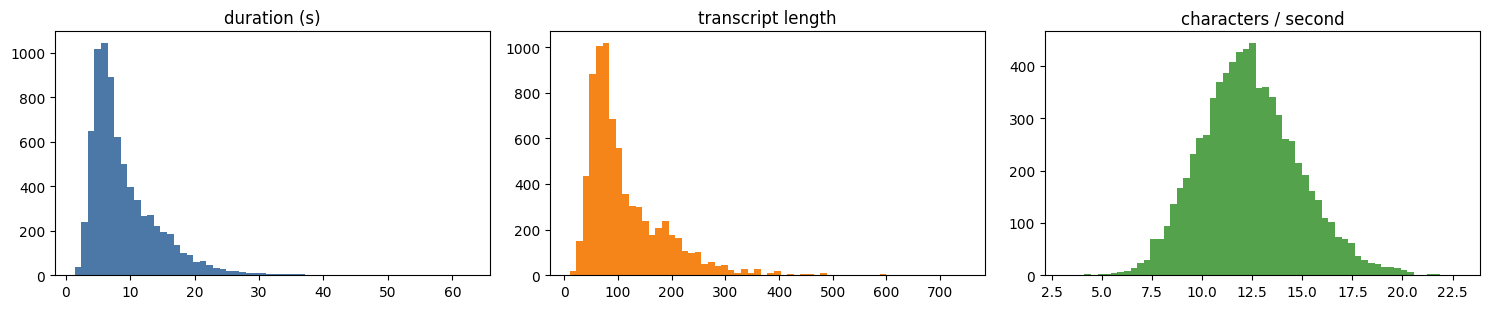

chars/sec mean 12.4  p99.5 19.6 | CTC frames 50 Hz


In [15]:
import matplotlib.pyplot as plt

all_text = "".join(train_df.transcription.astype(str))
char_counts = Counter(all_text)
print(f"{len(char_counts)} distinct characters")
print(repr("".join(sorted(char_counts))))
print("\nrare (<50):", {c: n for c, n in char_counts.items() if n < 50})

cps = train_df.transcription.astype(str).str.len() / train_df.duration
fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
ax[0].hist(train_df.duration, bins=60, color="#4C78A8"); ax[0].set_title("duration (s)")
ax[1].hist(train_df.transcription.astype(str).str.len(), bins=60, color="#F58518"); ax[1].set_title("transcript length")
ax[2].hist(cps, bins=60, color="#54A24B"); ax[2].set_title("characters / second")
plt.tight_layout(); plt.show()

out_fps = 25 if CFG.add_adapter else 50
print(f"chars/sec mean {cps.mean():.1f}  p99.5 {cps.quantile(0.995):.1f} | CTC frames {out_fps} Hz")
if cps.quantile(0.995) > out_fps * 0.7:
    print("!! label density high for this frame rate -> keep CFG.add_adapter = False")

In [16]:
KEEP_RARE_THRESHOLD = 10     # characters rarer than this cost more as output classes than they earn

DROP_CHARS = {c for c, n in char_counts.items() if n < KEEP_RARE_THRESHOLD and c != " "}
print("dropping:", DROP_CHARS if DROP_CHARS else "nothing")
_ws = re.compile(r"\s+")

def normalize(text: str) -> str:
    text = unicodedata.normalize("NFC", str(text))
    if DROP_CHARS:
        text = "".join(ch for ch in text if ch not in DROP_CHARS)
    return _ws.sub(" ", text).strip()

train_df["text"] = train_df["transcription"].apply(normalize)
before = len(train_df)
train_df = train_df[(train_df.text.str.len() > 0)
                    & (train_df.duration >= CFG.min_duration)
                    & (train_df.duration <= CFG.max_duration)].reset_index(drop=True)
print(f"kept {len(train_df)}/{before} clips ({train_df.duration.sum()/3600:.2f} h) "
      f"after the {CFG.min_duration}-{CFG.max_duration}s filter")

dropping: nothing
kept 6578/7574 clips (13.68 h) after the 0.4-15.0s filter


In [17]:
vocab_chars = [c for c in sorted(set("".join(train_df.text))) if c != " "]
vocab_dict = {c: i for i, c in enumerate(vocab_chars)}
vocab_dict["|"] = len(vocab_dict)        # word delimiter
vocab_dict["[UNK]"] = len(vocab_dict)
vocab_dict["[PAD]"] = len(vocab_dict)    # doubles as the CTC blank

with open(Path(CFG.output_dir) / "vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab_dict, f, ensure_ascii=False)
print(f"vocab size {len(vocab_dict)}:", vocab_dict)

vocab size 36: {'A': 0, 'G': 1, 'H': 2, 'J': 3, 'N': 4, 'O': 5, 'U': 6, 'a': 7, 'b': 8, 'c': 9, 'd': 10, 'e': 11, 'f': 12, 'g': 13, 'h': 14, 'i': 15, 'j': 16, 'k': 17, 'l': 18, 'm': 19, 'n': 20, 'o': 21, 'p': 22, 'q': 23, 'r': 24, 's': 25, 't': 26, 'u': 27, 'v': 28, 'w': 29, 'x': 30, 'y': 31, 'z': 32, '|': 33, '[UNK]': 34, '[PAD]': 35}


## 4. Pretrained weights and processor

Works both online (downloads from the Hub) and offline (finds a `wav2vec2-bert` checkpoint
added as a Kaggle Model/Dataset input).

In [18]:
from transformers import (
    Wav2Vec2CTCTokenizer,
    SeamlessM4TFeatureExtractor,
    Wav2Vec2BertProcessor,
    Wav2Vec2BertForCTC,
)

def find_local_w2vbert():
    for cfg_path in glob.glob("/kaggle/input/**/config.json", recursive=True):
        try:
            with open(cfg_path) as f:
                j = json.load(f)
        except Exception:
            continue
        if j.get("model_type") == "wav2vec2-bert":
            return str(Path(cfg_path).parent)
    return None

import socket

def hub_reachable(host="huggingface.co", port=443, timeout=5):
    try:
        socket.create_connection((host, port), timeout).close()
        return True
    except OSError:
        return False

LOCAL = find_local_w2vbert()
MODEL_PATH = LOCAL or CFG.model_id

if LOCAL:
    print("weights: local Kaggle input ->", MODEL_PATH)
elif hub_reachable():
    print("weights: downloading", MODEL_PATH, "from the Hugging Face Hub (~2.3 GB, one time)")
else:
    raise RuntimeError(
        "No local w2v-bert checkpoint under /kaggle/input and huggingface.co is unreachable.\n"
        "Fix either way:\n"
        "  - Settings > Internet = On (the menu reads 'Turn off internet' when it is already on), or\n"
        "  - Add Input > Models > search 'w2v-bert-2.0' > attach it, then re-run this cell."
    )

weights: downloading facebook/w2v-bert-2.0 from the Hugging Face Hub (~2.3 GB, one time)


In [19]:
tokenizer = Wav2Vec2CTCTokenizer(
    str(Path(CFG.output_dir) / "vocab.json"),
    unk_token="[UNK]", pad_token="[PAD]", word_delimiter_token="|", do_lower_case=False,
)
try:
    feature_extractor = SeamlessM4TFeatureExtractor.from_pretrained(MODEL_PATH)
except Exception as e:
    print("preprocessor_config.json unavailable, using the published w2v-bert-2.0 settings:", e)
    feature_extractor = SeamlessM4TFeatureExtractor(
        feature_size=80, num_mel_bins=80, sampling_rate=16_000,
        stride=2, padding_value=1.0, return_attention_mask=True,
    )
processor = Wav2Vec2BertProcessor(feature_extractor=feature_extractor, tokenizer=tokenizer)
processor.save_pretrained(CFG.output_dir)

# Round-trip check. decode() defaults to group_tokens=True, which applies the CTC collapse rule
# and merges repeated characters ("ll" -> "l"); label ids must be decoded with group_tokens=False.
demo = train_df.text.iloc[0]
ids = tokenizer(demo).input_ids
recon = tokenizer.decode(ids, group_tokens=False)
assert recon == demo, f"vocab does not round-trip:\n{demo}\n{recon}"
n_unk = sum(tokenizer(t).input_ids.count(tokenizer.unk_token_id) for t in train_df.text)
print(f"round-trip OK | [UNK] over the whole training set: {n_unk}")
print("features:", feature_extractor.num_mel_bins, "mels, stride", feature_extractor.stride)

round-trip OK | [UNK] over the whole training set: 0
features: 80 mels, stride 2


## 5. Audio pipeline

In [20]:
# soundfile decodes; the resampler is whichever of soxr/librosa/scipy is present.
# torchaudio is avoided on purpose: its compiled extension must match the exact torch build.
try:
    import soxr
    _RESAMPLER = "soxr"
except ImportError:
    try:
        import librosa
        _RESAMPLER = "librosa"
    except ImportError:
        from scipy.signal import resample_poly
        _RESAMPLER = "scipy"
print("resampler:", _RESAMPLER)


def resample(wav: np.ndarray, sr_in: int, sr_out: int) -> np.ndarray:
    if int(sr_in) == int(sr_out):
        return wav
    if _RESAMPLER == "soxr":
        return soxr.resample(wav, sr_in, sr_out)
    if _RESAMPLER == "librosa":
        return librosa.resample(wav, orig_sr=sr_in, target_sr=sr_out)
    from scipy.signal import resample_poly
    g = math.gcd(int(sr_in), int(sr_out))
    return resample_poly(wav, int(sr_out) // g, int(sr_in) // g).astype(np.float32)


def change_speed(wav: np.ndarray, factor: float) -> np.ndarray:
    # factor > 1 = faster/shorter. An exact small rational ratio keeps the polyphase filter cheap;
    # resampling to int(16000/0.9) would give gcd 1 and a 16000-tap filter per clip.
    if factor == 1.0:
        return wav
    fr = Fraction(1.0 / factor).limit_denominator(20)
    if _RESAMPLER == "scipy":
        from scipy.signal import resample_poly
        return resample_poly(wav, fr.numerator, fr.denominator).astype(np.float32)
    return resample(wav, fr.denominator, fr.numerator)


def load_audio(path: str, target_sr: int) -> np.ndarray:
    wav, sr = sf.read(path, dtype="float32", always_2d=False)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    if sr != target_sr:
        wav = resample(wav, sr, target_sr)
    return np.ascontiguousarray(wav, dtype=np.float32)


_w = load_audio(train_df.path.iloc[0], CFG.sampling_rate)
print(f"loaded {_w.shape} {_w.dtype} {len(_w)/CFG.sampling_rate:.2f}s peak {np.abs(_w).max():.3f}")
for f in CFG.speed_factors:
    t0 = time.time(); s = change_speed(_w, f)
    print(f"  speed {f}: {len(_w)} -> {len(s)} samples ({time.time()-t0:.4f}s)")

resampler: soxr
loaded (156000,) float32 9.75s peak 0.205
  speed 0.9: 156000 -> 173333 samples (0.0053s)
  speed 1.0: 156000 -> 156000 samples (0.0000s)
  speed 1.1: 156000 -> 141818 samples (0.0027s)


In [21]:
valid_df = train_df.sample(frac=CFG.valid_frac, random_state=CFG.seed)
fit_df   = train_df.drop(valid_df.index).reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
print(f"fit {len(fit_df)} | valid {len(valid_df)}")


class SpeechDataset(TorchDataset):
    def __init__(self, df, processor, train: bool):
        self.paths = df["path"].tolist()
        self.texts = df["text"].tolist() if "text" in df else None
        self.processor = processor
        self.train = train
        self.target_sr = CFG.sampling_rate

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        wav = load_audio(self.paths[idx], self.target_sr)

        # Speed perturbation resamples by 1/f and keeps calling it 16 kHz, so tempo and pitch
        # move together -- genuine speaker-rate augmentation, not a spectrogram trick.
        if self.train and CFG.speed_perturb:
            wav = change_speed(wav, random.choice(CFG.speed_factors))
        if self.train and CFG.gain_perturb:
            wav = np.clip(wav * (10 ** (random.uniform(-4, 4) / 20)), -1.0, 1.0).astype(np.float32)

        feats = self.processor.feature_extractor(
            wav, sampling_rate=self.target_sr, return_tensors="np"
        ).input_features[0]

        item = {"input_features": feats}
        if self.texts is not None:
            item["labels"] = self.processor.tokenizer(self.texts[idx]).input_ids
        return item


@dataclass
class CTCCollator:
    processor: Any

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch = self.processor.feature_extractor.pad(
            [{"input_features": f["input_features"]} for f in features],
            padding=True, return_tensors="pt",
        )
        if "labels" in features[0]:
            lab = self.processor.tokenizer.pad(
                [{"input_ids": f["labels"]} for f in features], padding=True, return_tensors="pt",
            )
            batch["labels"] = lab["input_ids"].masked_fill(lab.attention_mask.ne(1), -100)
        return batch


train_ds = SpeechDataset(fit_df, processor, train=True)
valid_ds = SpeechDataset(valid_df, processor, train=False)
collator = CTCCollator(processor=processor)
print({k: tuple(v.shape) for k, v in collator([train_ds[0], train_ds[1]]).items()})

fit 6381 | valid 197
{'input_features': (2, 442, 160), 'attention_mask': (2, 442), 'labels': (2, 130)}


## 6. Metric

CER is implemented here rather than pulled from `jiwer`, so the notebook runs with internet
disabled. It is the same quantity: Levenshtein distance over characters, summed over the
corpus and divided by the total reference length.

In [22]:
def _levenshtein(a, b) -> int:
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    if not b:
        return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]


def cer(refs: List[str], hyps: List[str]) -> float:
    dist = sum(_levenshtein(r, h) for r, h in zip(refs, hyps))
    total = sum(len(r) for r in refs)
    return dist / max(total, 1)


def wer(refs: List[str], hyps: List[str]) -> float:
    dist = sum(_levenshtein(r.split(), h.split()) for r, h in zip(refs, hyps))
    total = sum(len(r.split()) for r in refs)
    return dist / max(total, 1)


assert abs(cer(["salam dunya"], ["salam dunia"]) - 1 / 11) < 1e-9
print("CER implementation OK")


def preprocess_logits_for_metrics(logits, labels):
    if isinstance(logits, tuple):
        logits = logits[0]
    return logits.argmax(dim=-1)


def compute_metrics(pred):
    label_ids = np.where(pred.label_ids != -100, pred.label_ids, processor.tokenizer.pad_token_id)
    hyps = processor.batch_decode(pred.predictions)
    refs = processor.tokenizer.batch_decode(label_ids, group_tokens=False)
    return {"cer": cer(refs, hyps), "wer": wer(refs, hyps)}

CER implementation OK


## 7. Model

In [39]:
model_kwargs = dict(
    vocab_size=len(processor.tokenizer),
    pad_token_id=processor.tokenizer.pad_token_id,
    ctc_loss_reduction="mean",
    ctc_zero_infinity=CFG.ctc_zero_infinity,
    add_adapter=CFG.add_adapter,
    layerdrop=CFG.layerdrop,
    hidden_dropout=CFG.hidden_dropout,
    attention_dropout=CFG.attention_dropout,
    activation_dropout=CFG.activation_dropout,
    feat_proj_dropout=CFG.feat_proj_dropout,
    final_dropout=CFG.final_dropout,
    mask_time_prob=CFG.mask_time_prob,
    mask_time_length=CFG.mask_time_length,
    mask_feature_prob=CFG.mask_feature_prob,
    mask_feature_length=CFG.mask_feature_length,
)

# Wav2Vec2-BERT is a Conformer with relative position bias and has no SDPA kernel in
# transformers; it raises instead of falling back, so ask and accept eager if refused.
try:
    model = Wav2Vec2BertForCTC.from_pretrained(MODEL_PATH, attn_implementation="sdpa", **model_kwargs)
    ATTN = "sdpa"
except ValueError:
    model = Wav2Vec2BertForCTC.from_pretrained(MODEL_PATH, attn_implementation="eager", **model_kwargs)
    ATTN = "eager"

if CFG.grad_checkpointing:
    # use_reentrant=False is required here: the reentrant checkpoint implementation drops
    # gradients on DataParallel replicas, which is exactly the T4 x2 setup Kaggle hands out.
    model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
model.config.use_cache = False

print(f"{sum(p.numel() for p in model.parameters())/1e6:.0f} M params | attention {ATTN} | "
      f"{25 if CFG.add_adapter else 50} Hz CTC frames | vocab {model.config.vocab_size}")

Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

Wav2Vec2BertForCTC LOAD REPORT from: facebook/w2v-bert-2.0
Key            | Status  | 
---------------+---------+-
lm_head.weight | MISSING | 
lm_head.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


581 M params | attention eager | 50 Hz CTC frames | vocab 38


## 8. Trainer

Two additions beyond the defaults:

* **Length-grouped batching** — batches hold similar-length clips, removing most of the
  padding. Worth roughly 1.5–2× on this corpus.
* **Time budget callback** — stops cleanly at `CFG.time_budget_h` so a long run cannot eat
  the session that still has to produce the submission.

In [45]:
from transformers import Trainer, TrainingArguments, TrainerCallback
from transformers.trainer_pt_utils import LengthGroupedSampler


# A custom torch Dataset has no length column, so lengths are supplied explicitly.
class LengthGroupedTrainer(Trainer):
    def __init__(self, *args, train_lengths=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.train_lengths = train_lengths

    def _get_train_sampler(self, *args, **kwargs):
        if self.train_lengths is None:
            return super()._get_train_sampler(*args, **kwargs)
        return LengthGroupedSampler(
            batch_size=self.args.train_batch_size * self.args.gradient_accumulation_steps,
            dataset=self.train_dataset,
            lengths=self.train_lengths,
        )


class TimeBudgetCallback(TrainerCallback):
    def __init__(self, hours):
        self.limit, self.t0 = hours * 3600, None

    def on_train_begin(self, args, state, control, **kw):
        self.t0 = time.time()

    def on_step_end(self, args, state, control, **kw):
        if self.t0 and time.time() - self.t0 > self.limit:
            print(f"\n[time budget] {self.limit/3600:.1f} h reached — stopping.")
            control.should_training_stop = True
            control.should_save = True
        return control


use_bf16 = torch.cuda.is_bf16_supported()      # False on T4/P100 -> fp16
args = TrainingArguments(
    output_dir=CFG.output_dir,
    per_device_train_batch_size=CFG.batch_size,
    per_device_eval_batch_size=CFG.batch_size,
    gradient_accumulation_steps=CFG.grad_accum,
    num_train_epochs=CFG.epochs,
    learning_rate=CFG.lr,
    warmup_steps=50,
    weight_decay=CFG.weight_decay,
    lr_scheduler_type="linear",
    optim=CFG.optim,
    bf16=use_bf16,
    fp16=not use_bf16,
    gradient_checkpointing=CFG.grad_checkpointing,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    eval_strategy="steps",
    eval_steps=CFG.eval_steps,
    save_strategy="steps",
    save_steps=CFG.save_steps,
    save_total_limit=2,             # keeps best + latest; ~20 GB output quota
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
    logging_steps=CFG.logging_steps,
    dataloader_num_workers=CFG.num_workers,
    dataloader_pin_memory=True,
    remove_unused_columns=False,
    group_by_length=False,          # handled by LengthGroupedTrainer
    report_to="none",
    seed=CFG.seed,
)

trainer = LengthGroupedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=collator,
    compute_metrics=compute_metrics,
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,
    train_lengths=[int(d * CFG.sampling_rate) for d in fit_df["duration"]],
    callbacks=[TimeBudgetCallback(CFG.time_budget_h)],
)

steps_per_epoch = math.ceil(len(fit_df) / (CFG.batch_size * N_GPU * CFG.grad_accum))
print(f"precision {'bf16' if use_bf16 else 'fp16'} | {steps_per_epoch} steps/epoch | "
      f"{steps_per_epoch * CFG.epochs} steps total")
print("read s/it off the progress bar after ~30 steps and multiply to project the finish time")

precision bf16 | 200 steps/epoch | 400 steps total
read s/it off the progress bar after ~30 steps and multiply to project the finish time


## 9. Train

Re-running this cell resumes from the newest checkpoint rather than starting over. If a
finished model is already in the output directory, it loads that and skips training entirely
— which is what you want after a session restart when you only need to redo inference.

In [ ]:
final_model = Path(CFG.output_dir) / "model.safetensors"
ckpts = sorted(Path(CFG.output_dir).glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[1]))

if final_model.exists() and CFG.skip_train_if_done:
    print("finished model found — loading it and skipping training")
    model = Wav2Vec2BertForCTC.from_pretrained(CFG.output_dir)
    trainer.model = model
else:
    resume = str(ckpts[-1]) if ckpts else None
    print("resuming from:", resume)
    t0 = time.time()
    result = trainer.train(resume_from_checkpoint=resume)
    trainer.save_model(CFG.output_dir)
    processor.save_pretrained(CFG.output_dir)
    model = trainer.model
    print(f"trained {(time.time()-t0)/3600:.2f} h |", result.metrics)

resuming from: None


Step,Training Loss,Validation Loss


In [ ]:
hist = pd.DataFrame(trainer.state.log_history)
if "eval_cer" in hist:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    hist.dropna(subset=["loss"]).plot(x="step", y="loss", ax=ax[0], title="train loss")
    hist.dropna(subset=["eval_cer"]).plot(x="step", y=["eval_cer", "eval_wer"], ax=ax[1], title="validation")
    plt.tight_layout(); plt.show()
    print("best eval CER:", hist.eval_cer.min())

## 10. Decode

In [ ]:
@torch.no_grad()
def transcribe(df, model, batch_size=None):
    # Length-sorted batching for speed; results are returned in the original row order.
    batch_size = batch_size or CFG.infer_batch
    model = model.eval().to(DEVICE)
    order = np.argsort(df["duration"].values)
    ds = SpeechDataset(df.iloc[order].reset_index(drop=True), processor, train=False)

    out = [None] * len(df)
    amp_dtype = torch.bfloat16 if use_bf16 else torch.float16
    for start in range(0, len(ds), batch_size):
        chunk = [ds[i] for i in range(start, min(start + batch_size, len(ds)))]
        batch = {k: v.to(DEVICE) for k, v in collator(chunk).items() if k != "labels"}
        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            logits = model(**batch).logits.float()
        pred_ids = logits.argmax(-1).cpu().numpy()

        if "attention_mask" in batch:
            lens = model._get_feat_extract_output_lengths(batch["attention_mask"].sum(-1)).cpu().numpy()
        else:
            lens = np.full(len(chunk), logits.shape[1])
        for j in range(len(chunk)):
            out[order[start + j]] = processor.decode(pred_ids[j, : int(lens[j])])
        if start % (batch_size * 25) == 0:
            print(f"  {start}/{len(ds)}", end="\r")
    return out

In [ ]:
t0 = time.time()
val_hyp = transcribe(valid_df, model)
val_ref = valid_df["text"].tolist()
print(f"\nvalidation CER {cer(val_ref, val_hyp):.4f} | WER {wer(val_ref, val_hyp):.4f} "
      f"({time.time()-t0:.0f}s)")

per_utt = pd.DataFrame({"ref": val_ref, "hyp": val_hyp,
                        "cer": [cer([r], [h]) for r, h in zip(val_ref, val_hyp)]}).sort_values("cer", ascending=False)
print("\n--- worst 3 ---")
for _, r in per_utt.head(3).iterrows():
    print(f"[{r.cer:.3f}]\n  REF {r.ref}\n  HYP {r.hyp}")
print("\n--- best 3 ---")
for _, r in per_utt.tail(3).iterrows():
    print(f"[{r.cer:.3f}]\n  REF {r.ref}\n  HYP {r.hyp}")

In [ ]:
# Which characters go wrong most often — tells you whether the loss is still in the
# "learning the alphabet" phase or down to genuine acoustic confusions.
import difflib

conf = Counter()
for r, h in zip(val_ref, val_hyp):
    for tag, i1, i2, j1, j2 in difflib.SequenceMatcher(None, r, h, autojunk=False).get_opcodes():
        if tag == "replace":
            for a, b in zip(r[i1:i2], h[j1:j2]):
                conf[(a, b)] += 1
        elif tag == "delete":
            for a in r[i1:i2]:
                conf[(a, "-")] += 1
        elif tag == "insert":
            for b in h[j1:j2]:
                conf[("-", b)] += 1

print("top 20 confusions (ref -> hyp):")
for (a, b), n in conf.most_common(20):
    print(f"  {a!r} -> {b!r}  {n}")

## 11. Submission

In [ ]:
t0 = time.time()
test_hyp = transcribe(test_df, model)
print(f"\ndecoded {len(test_hyp)} test clips in {time.time()-t0:.0f}s")

sub = pd.DataFrame({"ID": test_df["ID"], "transcription": test_hyp})
sub["transcription"] = sub["transcription"].fillna("").str.strip()

n_empty = int((sub.transcription.str.len() == 0).sum())
print("empty predictions:", n_empty)
if n_empty:
    # an empty string scores as a full deletion; a frequent word is a marginally better guess
    sub.loc[sub.transcription.str.len() == 0, "transcription"] = _common

assert len(sub) == len(sample_df), f"row count {len(sub)} != {len(sample_df)}"
assert set(sub.ID) == set(sample_df.ID), "ID set does not match sample.csv"
sub = sub.set_index("ID").loc[sample_df.ID].reset_index()

sub.to_csv(CFG.submission, index=False)
print("wrote", CFG.submission, sub.shape)
display(sub.head())
print(f"mean predicted length {sub.transcription.str.len().mean():.1f} "
      f"vs train mean {fit_df.text.str.len().mean():.1f}")

In [ ]:
# Free the 20 GB output quota: checkpoints are only useful while the session lives.
# Comment this out if you want to keep the weights as a versioned notebook output.
import shutil

for c in Path(CFG.output_dir).glob("checkpoint-*"):
    shutil.rmtree(c, ignore_errors=True)
!du -sh /kaggle/working/* 2>/dev/null

## 12. What to try next, in order of payoff per hour

1. **More epochs.** CTC on 18 h keeps improving well past 8 epochs. The resume logic above
   makes this cheap: raise `CFG.epochs`, re-run, it continues from the last checkpoint.
   Prefer a *finished* shorter schedule over a truncated long one — linear decay that never
   reaches zero leaves the model at a high-LR, under-converged point.
2. **A KenLM 5-gram over the training transcriptions** with `pyctcdecode`, typically 10–20 %
   relative CER for no retraining. Needs internet plus a `lmplz` build, so do it only once
   the plain model is safely submitted.
3. **Pseudo-labelling.** Decode the test clips, keep the ~60 % with the highest mean
   per-frame log-probability, append them to `fit_df`, fine-tune a few more epochs. Free
   in-domain data drawn from exactly the test distribution.
4. **Checkpoint averaging.** Mean the weights of the last 3–5 checkpoints; small but reliable,
   and one forward pass tells you whether it helped.
5. **A bigger effective batch.** If you land on a P100 or a larger card, raise
   `CFG.batch_size` — CTC likes large batches and the length-grouped sampler keeps padding low.